In [17]:
import numpy as np
import pandas as pd
bostonDF = pd.read_csv('/content/drive/MyDrive/data/boston.csv')

from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
bostonDF.head(3)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7


In [20]:
bostonDF.rename(columns={'crim':'CRIM', 'zn':'ZN', 'indus':'INDUS', 'chas':'CHAS', 'nox':'NOX', 'rm':'RM', 'age':'AGE', 'dis':'DIS',
                         'rad':'RAD', 'tax':'TAX', 'ptratio':'PTRATIO', 'b':'B', 'lstat':'LSTAT', 'medv':'PRICE'}, inplace=True)

bostonDF['RM'].fillna(bostonDF['RM'].mean(), inplace=True)


y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace = False)

<ipython-input-20-1cf61a0da300>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bostonDF['RM'].fillna(bostonDF['RM'].mean(), inplace=True)


In [21]:
#alpha=10으로 설정해 릿지 회귀 수행
ridge = Ridge(alpha=10)
neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring='neg_mean_squared_error', cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(' 5 folds의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 3))
print(' 5 folds의 개별 RMSE scores: ', np.round(rmse_scores, 3))
print(' 5 folds의 평균 RMSE: {0:3f}'.format(avg_rmse))

 5 folds의 개별 Negative MSE scores:  [-11.656 -24.373 -28.3   -74.564 -28.572]
 5 folds의 개별 RMSE scores:  [3.414 4.937 5.32  8.635 5.345]
 5 folds의 평균 RMSE: 5.530211


In [22]:
# 릿지에 사용될 alpha 파라미터의 값을 정의
alphas = [0, 0.1, 1, 10, 100]

# alphas list 값을 반복하면서 alpha에 따른 평균 rmse를 구함
for alpha in alphas:
    ridge = Ridge(alpha = alpha)

    # cross_val_score를 이용해 5 폴드의 평균 RMSE를 계산
    neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring='neg_mean_squared_error', cv = 5)
    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
    print('alpha {0}일 때 5 folds의 평균 RMSE: {1:.3f}'.format(alpha, avg_rmse))

alpha 0일 때 5 folds의 평균 RMSE: 5.840
alpha 0.1일 때 5 folds의 평균 RMSE: 5.800
alpha 1일 때 5 folds의 평균 RMSE: 5.666
alpha 10일 때 5 folds의 평균 RMSE: 5.530
alpha 100일 때 5 folds의 평균 RMSE: 5.336


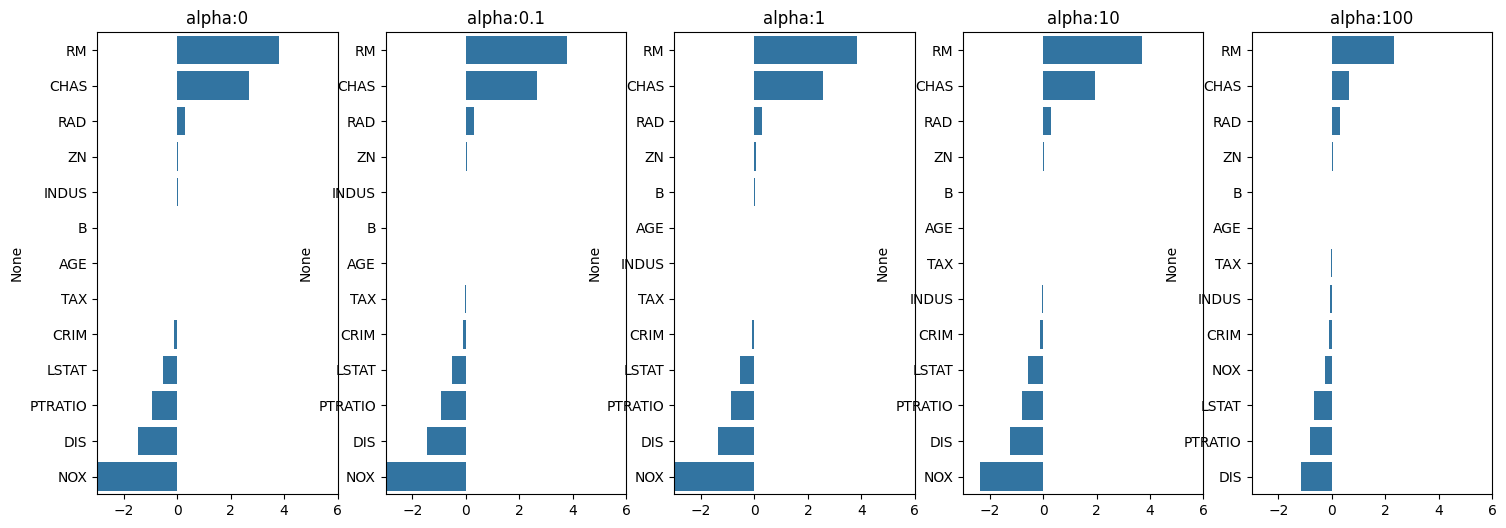

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
# 각 alpha에 따른 회귀 계수 값을 시각화하기 위해 5개의 열로 된 맷플롯립 축 생성
fig, axs = plt.subplots(figsize=(18, 6), nrows = 1, ncols = 5)
# 각 alpha에 따른 회귀 계수 값을 데이터로 저장하기 위한 DataFrame 생성
coeff_df = pd.DataFrame()

# alphas 리스트 값을 차례로 입력해 회귀 계수 값 시각화 및 데이터 저장. pos는 axis의 위치 지정
for pos, alpha in enumerate(alphas) :
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_data, y_target)
    # alpha에 따른 피처별로 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가.
    coeff = pd.Series(data = ridge.coef_, index = X_data.columns)
    colname = 'alpha:'+str(alpha)
    coeff_df[colname] = coeff
    # 막대 그래프로 각 alpha 값에서의 회귀 계수를 시각화. 회귀 계수값이 높은 순으로 표현
    coeff = coeff.sort_values(ascending = False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-3, 6)
    sns.barplot(x=coeff.values, y=coeff.index, ax=axs[pos])

# for 문 바깥에서 맷플롯립의 show 호출 및 alpha에 따른 피처별 회귀 계수를 DataFrame으로 표시
plt.show()
# alpha 값을 계속 증가시킬수록 회귀 계수 값은 지속적으로 작아짐

In [27]:
ridge_alphas = [0, 0.1, 1, 10, 100]
sort_column = 'alpha:'+str(ridge_alphas[0])
coeff_df.sort_values(by=sort_column, ascending = False)

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
RM,3.791638,3.800255,3.837370,3.687519,2.322956
CHAS,2.687541,2.670827,2.553202,1.952688,0.638502
RAD,0.307896,0.305365,0.292008,0.281405,0.316517
ZN,0.046482,0.046631,0.047493,0.049621,0.054557
INDUS,0.021963,0.017423,-0.007274,-0.041385,-0.051939
B,0.009311,0.009368,0.009673,0.010037,0.009391
AGE,0.000964,0.000004,-0.005135,-0.010430,0.001382
TAX,-0.012426,-0.012512,-0.013002,-0.014077,-0.015909
CRIM,-0.108055,-0.107518,-0.104645,-0.101495,-0.102257
LSTAT,-0.525855,-0.527042,-0.534304,-0.560170,-0.661398


In [28]:
from sklearn.linear_model import Lasso, ElasticNet

# alpha 값에 따른 회귀 모델의 폴드 평균 RMSE를 출력하고 회귀 계수값들을 DataFrame으로 반환
def get_linear_reg_eval(model_name, params = None, X_data_n = None, y_target_n = None, verbose = True, return_coeff = True):
    coeff_df = pd.DataFrame()
    if verbose : print('#######', model_name, '#######')
    for param in params:
        if model_name =='Ridge': model = Ridge(alpha=param)
        elif model_name =='Lasso': model = Lasso(alpha=param)
        elif model_name =='ElasticNet': model = ElasticNet(alpha=param, l1_ratio = 0.7)
        neg_mse_scores = cross_val_score(model, X_data_n, y_target_n, scoring='neg_mean_squared_error', cv=5)
        avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
        print('alpha {0}일 때 5 폴드 세트의 평균 RMSE: {1:.3f} '.format(param, avg_rmse))
        # cross_val_score는 evaluation metric만 반환하므로 모델을 다시 학습하여 회귀 계수 추출

        model.fit(X_data_n, y_target_n)
        if return_coeff:
            # alpha에 따른 피처별 회귀 계수를 Series로 반환하고 이를 DataFrame의 칼럼으로 추가
            coeff = pd.Series(data = model.coef_, index = X_data_n.columns )
            colname = 'alpha:'+str(param)
            coeff_df[colname] = coeff

    return coeff_df
# end of get_linear_regre_eval

In [29]:
# 라쏘에 사용될 alpha 파라미터의 값을 정의하고 get_linear_reg_eval()함수 호출
lasso_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df = get_linear_reg_eval('Lasso', params=lasso_alphas, X_data_n=X_data, y_target_n=y_target)

####### Lasso #######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE: 5.626 
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.628 
alpha 0.5일 때 5 폴드 세트의 평균 RMSE: 5.679 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.779 
alpha 3일 때 5 폴드 세트의 평균 RMSE: 6.189 


In [30]:
# 반환된 coeff_lasso_df를 첫 번째 칼럼순으로 내림차순 정렬해 회귀계수 DataFrame 출력
sort_column = 'alpha:'+str(lasso_alphas[0])
coeff_lasso_df.sort_values(by=sort_column, ascending = False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,3.775223,3.688587,2.481670,0.929941,0.000000
CHAS,1.435265,0.956116,0.000000,0.000000,0.000000
RAD,0.272796,0.276535,0.278843,0.265012,0.061864
ZN,0.049092,0.049246,0.049603,0.049255,0.037231
B,0.010248,0.010249,0.009464,0.008237,0.006510
NOX,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
AGE,-0.011416,-0.009751,0.003837,0.021079,0.042495
TAX,-0.014375,-0.014653,-0.015504,-0.015241,-0.008602
INDUS,-0.040449,-0.034993,-0.004268,-0.000000,-0.000000
CRIM,-0.098253,-0.097954,-0.083342,-0.063486,-0.000000


In [31]:
# 엘라스틱넷에 사용될 alpha 파라미터의 값들을 정의하고 get_linear_reg_eval() 함수 호출
# l1_ration는 0.7로 고정 (단순히 alpha값의 변화만 살펴보기 위해 고정시킴)
elastic_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params = elastic_alphas,
                                       X_data_n=X_data, y_target_n = y_target)

####### ElasticNet #######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE: 5.554 
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.537 
alpha 0.5일 때 5 폴드 세트의 평균 RMSE: 5.473 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.599 
alpha 3일 때 5 폴드 세트의 평균 RMSE: 6.068 


In [32]:
# 반환된 coeff_elastic_df를 첫 번째 칼럼순으로 내림차순 정렬해 회귀셰수 DataFrame 출력
sort_column = 'alpha:'+str(elastic_alphas[0])
coeff_elastic_df.sort_values(by = sort_column, ascending = False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,3.559770,3.399754,1.906012,0.929343,0.000000
CHAS,1.331365,0.980309,0.000000,0.000000,0.000000
RAD,0.280631,0.285141,0.301790,0.289801,0.146846
ZN,0.050148,0.050660,0.052938,0.052179,0.038268
B,0.010122,0.010066,0.009111,0.008315,0.007020
AGE,-0.009847,-0.008013,0.007922,0.020447,0.043446
TAX,-0.014603,-0.014891,-0.016092,-0.016235,-0.011417
INDUS,-0.043334,-0.041259,-0.022552,-0.000000,-0.000000
CRIM,-0.099527,-0.099274,-0.089118,-0.073619,-0.019058
NOX,-0.169149,-0.000000,-0.000000,-0.000000,-0.000000


In [33]:
# method는 표준 정규 분포 변환(Standard), 최댓값/최솟값 정규화(MinMax), 로그변환(Log) 결정
# p_degree는 다항식 특성을 추가할 때 적용. p_degree는 2 이상 부여하지 않음.
def get_scaled_data(method='None', p_degree = None, input_data = None):
    if method == 'Standard':
        scaled_data = StandardScaler().fit_transform(input_data)
    elif method == 'MinMax':
        scaled_data = MinMaxScaler().fit_transform(input_data)
    elif method == 'Log':
        scaled_data = np.log1p(input_data)
    else:
        scaled_data = input_data

    if p_degree != None:
        scaled_data = PolynomialFeatures(degree=p_degree, include_bias = False).fit_transform(scaled_data)


    return scaled_data

In [39]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
# Ridge의 alpha값을 다르게 적용하고 다양한 데이터 변환 방법에 따른 RMSE 추출.
alphas = [0.1, 1, 10, 100]

# 5개 방식으로 변환. 먼저 원본 그대로, 표준정규 분포, 표준정규 분포+다항식 특성
# 최대/최소 정규화, 최대/최소 정규화 + 다항식 특성, 로그변환
scale_methods = [(None, None), ('Standard', None), ('Standard', 2), ('MinMax', None), ('MinMax', 2), ('Log',None)]
for scale_method in scale_methods:
    X_data_scaled = get_scaled_data(method=scale_method[0], p_degree = scale_method[1], input_data = X_data)
    print('\n## 변환 유형:{0}, Polynomial Degree:{1}'.format(scale_method[0], scale_method[1]))
    get_linear_reg_eval('Ridge', params = alphas, X_data_n = X_data_scaled,
                        y_target_n = y_target, verbose = False, return_coeff = False)


## 변환 유형:None, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.800 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.666 
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.530 
alpha 100일 때 5 폴드 세트의 평균 RMSE: 5.336 

## 변환 유형:Standard, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.837 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.814 
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.649 
alpha 100일 때 5 폴드 세트의 평균 RMSE: 5.431 

## 변환 유형:Standard, Polynomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 8.907 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 6.956 
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.511 
alpha 100일 때 5 폴드 세트의 평균 RMSE: 4.641 

## 변환 유형:MinMax, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.775 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.475 
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.758 
alpha 100일 때 5 폴드 세트의 평균 RMSE: 7.635 

## 변환 유형:MinMax, Polynomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.317 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 4.338 
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.194 
alpha 100일 때 5 폴드 세트의 평균 RMSE: 6.539 

## 변환 유형:Log, Polynomial Degree:None
alpha 0.1일 때 5 폴

In [40]:
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# StandardScaler()로 평균이 0, 분산 1로 데이터 분포도 변환
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, cancer.target,
                                                    test_size = 0.3, random_state = 0)

In [44]:
from sklearn.metrics import accuracy_score, roc_auc_score

# 로지스틱 회귀를 이용하여 학습 및 예측 수행
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)

# accuracy와 roc_auc 측정
print('accuracy: {:0.3f}' .format(accuracy_score(y_test, lr_preds)))
print('roc_auc: {:0.3f}'.format(roc_auc_score(y_test, lr_preds)))

accuracy: 0.977
roc_auc: 0.972


In [49]:
from sklearn.model_selection import GridSearchCV

params = {'penalty':['l2','l1'],
          'C':[0.01, 0.1, 1, 5, 10]}

grid_clf = GridSearchCV(lr_clf, param_grid = params, scoring = 'accuracy', cv = 3)
grid_clf.fit(data_scaled, cancer.target)
print('최적 하이퍼 파라미터:{0}, 최적 평균 정확도:{1:.3f}'.format(grid_clf.best_params_,
                                                         grid_clf.best_score_))

최적 하이퍼 파라미터:{'C': 1, 'penalty': 'l2'}, 최적 평균 정확도:0.975


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver